# Movie Data Exploratory Analysis

## Project Overview

This notebook explores a large movie dataset containing information about movie releases, genres, languages, budgets, revenues, ratings, popularity, runtime, cast, crew, production companies, and directors.

The analysis focuses on understanding the dataset, assessing data quality, preparing the data for analysis, exploring key patterns, and answering practical questions related to movie performance and production.

### Dataset Size

- **44,691 movies**
- **19 original features**

### Analysis Areas

- Dataset structure and data quality
- Missing-value analysis
- Movie release trends
- Ratings and popularity
- Budget and revenue
- Runtime
- Production companies
- Directors and movie performance

## 1. Import Libraries

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [119]:
df = pd.read_csv("../data/movies_complete.csv")

df.head()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,production_countries,vote_count,vote_average,popularity,runtime,cast,cast_size,crew_size,director
0,862,Toy Story,NaN,10/30/1995,Animation|Comedy|Family,Toy Story Collection,en,30.0,373.554033,Pixar Animation Studios,United States of America,5415,7.7,21.946943,81.0,Tom Hanks|Tim Allen|Don Rickles|Jim Varney|Wal...,13,106,John Lasseter
1,8844,Jumanji,Roll the dice and unleash the excitement!,12/15/1995,Adventure|Fantasy|Family,NaN,en,65.0,262.797249,TriStar Pictures|Teitler Film|Interscope Commu...,United States of America,2413,6.9,17.015539,104.0,Robin Williams|Jonathan Hyde|Kirsten Dunst|Bra...,26,16,Joe Johnston
2,15602,Grumpier Old Men,Still Yelling. Still Fighting. Still Ready for...,12/22/1995,Romance|Comedy,Grumpy Old Men Collection,en,NaN,NaN,Warner Bros.|Lancaster Gate,United States of America,92,6.5,11.712900,101.0,Walter Matthau|Jack Lemmon|Ann-Margret|Sophia ...,7,4,Howard Deutch
3,31357,Waiting to Exhale,Friends are the people who let you be yourself...,12/22/1995,Comedy|Drama|Romance,NaN,en,16.0,81.452156,Twentieth Century Fox Film Corporation,United States of America,34,6.1,3.859495,127.0,Whitney Houston|Angela Bassett|Loretta Devine|...,10,10,Forest Whitaker
4,11862,Father of the Bride Part II,Just When His World Is Back To Normal... He's ...,2/10/1995,Comedy,Father of the Bride Collection,en,NaN,76.578911,Sandollar Productions|Touchstone Pictures,United States of America,173,5.7,8.387519,106.0,Steve Martin|Diane Keaton|Martin Short|Kimberl...,12,7,Charles Shyer


## 3. Dataset Overview

### Feature Description

| Feature | Description |
|---|---|
| `id` | Unique movie identifier |
| `title` | Movie title |
| `tagline` | Movie tagline |
| `release_date` | Movie release date |
| `genres` | Movie genres |
| `belongs_to_collection` | Movie collection/franchise |
| `original_language` | Original movie language |
| `budget_musd` | Movie budget in million USD |
| `revenue_musd` | Movie revenue in million USD |
| `production_companies` | Production companies |
| `production_countries` | Production countries |
| `vote_count` | Number of votes |
| `vote_average` | Average movie rating |
| `popularity` | Popularity score |
| `runtime` | Movie runtime in minutes |
| `cast` | Cast members |
| `cast_size` | Number of cast members |
| `crew_size` | Number of crew members |
| `director` | Movie director |

In [123]:
print(f"Dataset contains {df.shape[0]:,} movies and {df.shape[1]} features.")

Dataset contains 44,691 movies and 19 features.


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44691 entries, 0 to 44690
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     44691 non-null  int64  
 1   title                  44691 non-null  object 
 2   tagline                20284 non-null  object 
 3   release_date           44657 non-null  object 
 4   genres                 42586 non-null  object 
 5   belongs_to_collection  4463 non-null   object 
 6   original_language      44681 non-null  object 
 7   budget_musd            8854 non-null   float64
 8   revenue_musd           7385 non-null   float64
 9   production_companies   33356 non-null  object 
 10  production_countries   38835 non-null  object 
 11  vote_count             44691 non-null  int64  
 12  vote_average           42077 non-null  float64
 13  popularity             44691 non-null  float64
 14  runtime                43179 non-null  float64
 15  ca

In [127]:
df.describe()

,id,budget_musd,revenue_musd,vote_count,vote_average,popularity,runtime,cast_size,crew_size
count,44691.000000,8854.000000,7385.000000,44691.000000,42077.000000,44691.000000,43179.000000,44691.000000,44691.000000
mean,107186.242845,21.669886,68.968649,111.653778,6.003341,2.957460,97.566850,12.479090,10.313643
std,111806.362236,34.359837,146.608966,495.322313,1.281060,6.040008,34.653409,12.124663,15.892154
min,2.000000,0.000001,0.000001,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,26033.500000,2.000000,2.405420,3.000000,5.300000,0.402038,86.000000,6.000000,2.000000
50%,59110.000000,8.200000,16.872671,10.000000,6.100000,1.150055,95.000000,10.000000,6.000000
75%,154251.000000,25.000000,67.642693,35.000000,6.800000,3.768882,107.000000,15.000000,12.000000
max,469172.000000,380.000000,2787.965087,14075.000000,10.000000,547.488298,1256.000000,313.000000,435.000000


In [129]:
df.dtypes

id                         int64
title                     object
tagline                   object
release_date              object
genres                    object
belongs_to_collection     object
original_language         object
budget_musd              float64
revenue_musd             float64
production_companies      object
production_countries      object
vote_count                 int64
vote_average             float64
popularity               float64
runtime                  float64
cast                      object
cast_size                  int64
crew_size                  int64
director                  object
dtype: object

## 4. Data Quality Assessment

### Missing Values

In [132]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": df.isnull().mean() * 100
})

missing = missing[missing["Missing Values"] > 0].sort_values(
    "Missing %",
    ascending=False
)

missing

,Missing Values,Missing %
belongs_to_collection,40228,90.013649
revenue_musd,37306,83.475420
budget_musd,35837,80.188405
tagline,24407,54.612786
production_companies,11335,25.363048
production_countries,5856,13.103309
vote_average,2614,5.849052
cast,2189,4.898078
genres,2105,4.710121
runtime,1512,3.383232


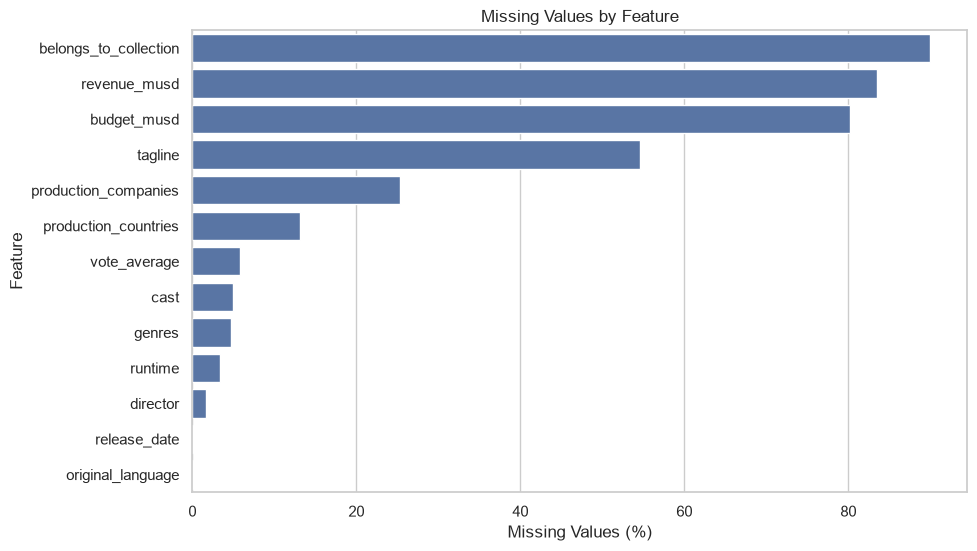

In [134]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=missing.reset_index(),
    x="Missing %",
    y="index"
)

plt.title("Missing Values by Feature")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.show()

### Duplicate Records

In [137]:
print(f"Duplicate rows: {df.duplicated().sum():,}")

Duplicate rows: 0


### Date Preparation

In [140]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = df["release_date"].dt.year

In [142]:
df_clean["release_year"] = df_clean["release_year"].astype("Int64")

In [144]:
df_clean[["release_date", "release_year"]].head()

,release_date,release_year
0,1995-10-30,1995
1,1995-12-15,1995
2,1995-12-22,1995
3,1995-12-22,1995
4,1995-02-10,1995


## 5. Data Cleaning

### Cleaning Strategy

The dataset contains missing values across several features. Instead of removing large numbers of records or replacing all missing values with zero, missing data will be handled according to the meaning and analytical purpose of each feature.

The cleaning process will:

- Remove records without a valid movie title.
- Convert release dates to a consistent datetime format.
- Create a release year feature for temporal analysis.
- Preserve missing financial values because missing budget or revenue does not necessarily mean zero.
- Replace missing categorical/text fields only where a meaningful "Unknown" category is appropriate.
- Handle invalid or unrealistic numerical values before analysis.

In [148]:
# Create a working copy
df_clean = df.copy()

print(f"Initial rows: {len(df_clean):,}")

Initial rows: 44,691


In [150]:
# Remove rows without a movie title
df_clean = df_clean.dropna(subset=["title"])

print(f"Rows after removing missing titles: {len(df_clean):,}")

Rows after removing missing titles: 44,691


In [152]:
# Check invalid release dates
print(f"Missing release dates: {df_clean['release_date'].isna().sum():,}")

Missing release dates: 112


### Handling Missing Categorical Values

Missing values in categorical and descriptive fields are replaced with `"Unknown"` where the field is useful for grouping or analysis.

Financial variables such as budget and revenue are intentionally left missing because an unavailable value does not necessarily represent zero.

In [155]:
categorical_cols = [
    "genres",
    "belongs_to_collection",
    "original_language",
    "production_companies",
    "production_countries",
    "director"
]

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")

In [157]:
df_clean[categorical_cols].isnull().sum()

genres                   0
belongs_to_collection    0
original_language        0
production_companies     0
production_countries     0
director                 0
dtype: int64

### Numerical Data Validation

Numerical variables are inspected for invalid or unrealistic values before analysis.

Budget and revenue missing values are preserved because they represent unavailable financial information rather than confirmed zero values.

In [160]:
numeric_cols = [
    "budget_musd",
    "revenue_musd",
    "vote_count",
    "vote_average",
    "popularity",
    "runtime",
    "cast_size",
    "crew_size"
]

df_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
budget_musd,8854.0,21.669886,34.359837,0.000001,2.000000,8.200000,25.000000,380.000000
revenue_musd,7385.0,68.968649,146.608966,0.000001,2.405420,16.872671,67.642693,2787.965087
vote_count,44691.0,111.653778,495.322313,0.000000,3.000000,10.000000,35.000000,14075.000000
vote_average,42077.0,6.003341,1.281060,0.000000,5.300000,6.100000,6.800000,10.000000
popularity,44691.0,2.957460,6.040008,0.000000,0.402038,1.150055,3.768882,547.488298
runtime,43179.0,97.566850,34.653409,1.000000,86.000000,95.000000,107.000000,1256.000000
cast_size,44691.0,12.479090,12.124663,0.000000,6.000000,10.000000,15.000000,313.000000
crew_size,44691.0,10.313643,15.892154,0.000000,2.000000,6.000000,12.000000,435.000000


### Cleaned Dataset Summary

In [163]:
print(f"Original rows: {len(df):,}")
print(f"Cleaned rows: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")
print(f"Columns: {df_clean.shape[1]}")

Original rows: 44,691
Cleaned rows: 44,691
Rows removed: 0
Columns: 20


## 6. Exploratory Data Analysis

### 6.1 Movie Releases Over Time

Understanding how movie production has changed over time helps identify long-term growth, periods of expansion, and changes in the volume of movies released.

In [167]:
release_trend = (
    df_clean.dropna(subset=["release_year"])
    .groupby("release_year")
    .size()
    .reset_index(name="movie_count")
)

release_trend.head()

,release_year,movie_count
0,1900.0,10
1,1901.0,10
2,1902.0,2
3,1903.0,18
4,1904.0,7


In [169]:
release_trend.tail(10)

,release_year,movie_count
108,2008.0,1454
109,2009.0,1567
110,2010.0,1469
111,2011.0,1632
112,2012.0,1703
113,2013.0,1870
114,2014.0,1949
115,2015.0,1867
116,2016.0,1573
117,2017.0,503


> **Note:** The dataset contains substantially fewer records for 2017 than the preceding years, suggesting that the final year may be incomplete. Therefore, 2017 is excluded from the release-trend visualization to avoid misleading interpretation.

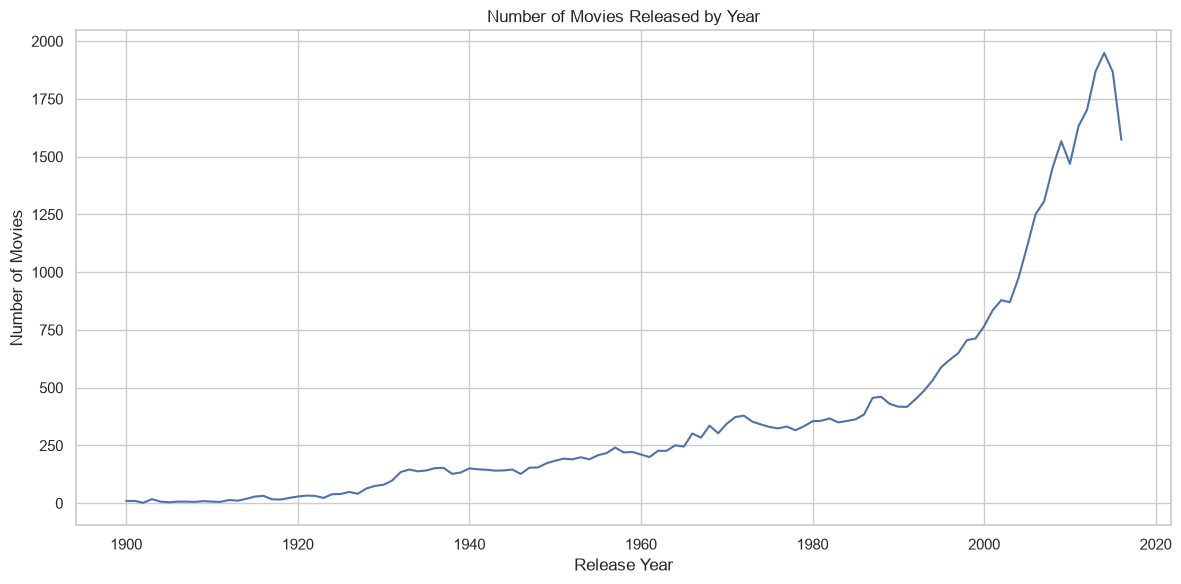

In [172]:
# Exclude the incomplete final year from the trend visualization
release_trend_plot = release_trend[
    release_trend["release_year"] < 2017
]

plt.figure(figsize=(12, 6))

plt.plot(
    release_trend_plot["release_year"],
    release_trend_plot["movie_count"]
)

plt.title("Number of Movies Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

### 6.2 Movie Ratings and Popularity

Movie ratings and popularity provide different perspectives on audience response. 
Ratings reflect the average score given by users, while popularity represents the 
relative level of attention received by a movie.

This section examines the distribution of ratings and explores the relationship 
between audience ratings, vote counts, and movie popularity.

#### 6.2.1 Distribution of Movie Ratings

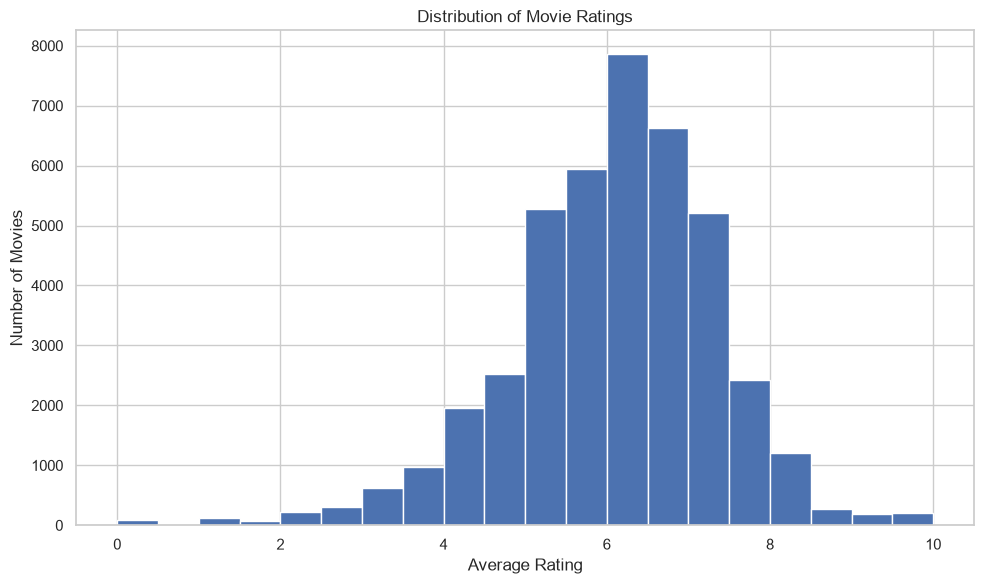

In [176]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["vote_average"].dropna(),
    bins=20
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

**Interpretation:** Movie ratings are concentrated around the mid-to-high range, with most movies receiving average ratings between approximately 5 and 8. Very low and very high ratings are less common, indicating that extreme ratings represent a relatively small portion of the dataset.

#### 6.2.2 Movie Ratings vs Popularity

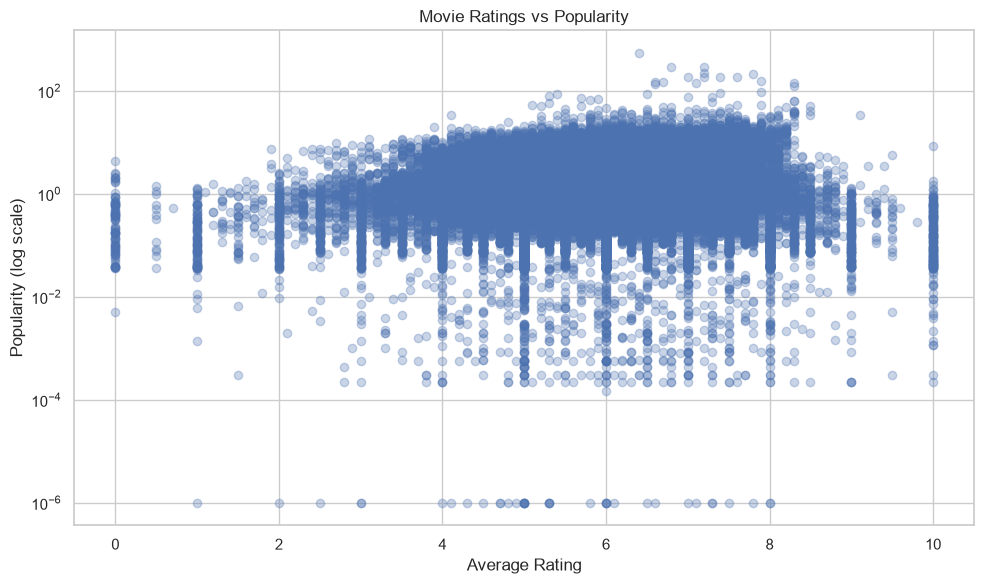

In [179]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["vote_average"],
    df_clean["popularity"],
    alpha=0.3
)

plt.yscale("log")

plt.title("Movie Ratings vs Popularity")
plt.xlabel("Average Rating")
plt.ylabel("Popularity (log scale)")
plt.tight_layout()
plt.show()

**Interpretation:** The relationship between average rating and popularity appears weak and highly dispersed. Movies with similar ratings can have substantially different popularity levels, suggesting that popularity is influenced by factors beyond audience rating alone. The logarithmic scale helps reveal variation across the wide range of popularity values.

### 6.3 Audience Engagement and Popularity

Vote count provides an indication of how many users actively rated a movie, while popularity measures the level of attention received by the movie.

This section examines whether movies with more audience engagement, measured by vote count, also tend to have higher popularity.

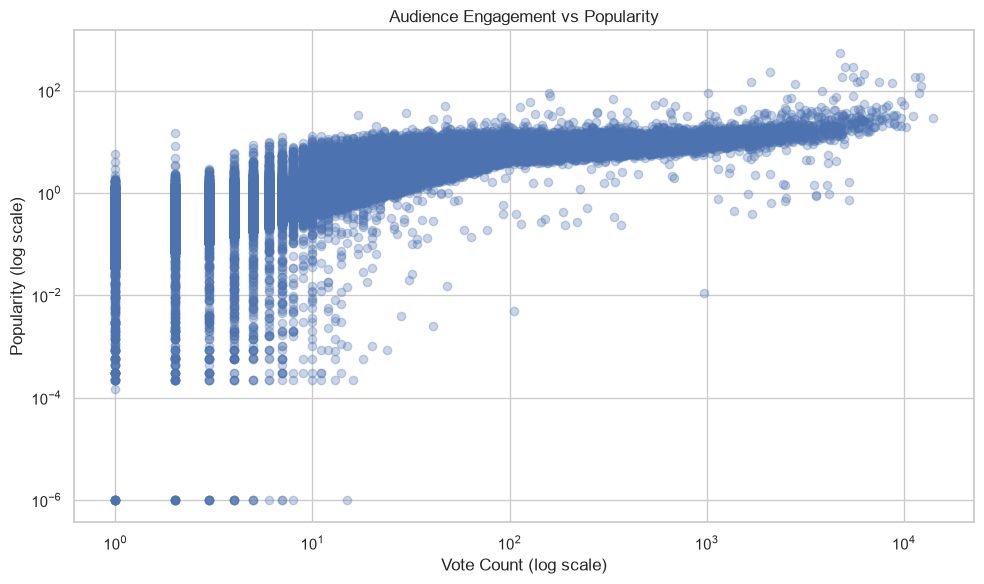

In [183]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["vote_count"],
    df_clean["popularity"],
    alpha=0.3
)

plt.xscale("log")
plt.yscale("log")

plt.title("Audience Engagement vs Popularity")
plt.xlabel("Vote Count (log scale)")
plt.ylabel("Popularity (log scale)")
plt.tight_layout()
plt.show()

**Interpretation:** The analysis shows a clear positive relationship between audience engagement and movie popularity. Movies with higher vote counts generally tend to have higher popularity, although substantial variation exists at lower levels of audience engagement. This suggests that audience attention and engagement are important factors associated with movie popularity, but the relationship is not perfectly linear.

### 6.4 Movie Genres and Popularity

Genres provide insight into the types of movies that attract audience attention. This section compares movie popularity across major genres to identify which genres tend to receive greater audience interest.

In [189]:
genre_popularity = (
    df_clean[["genres", "popularity"]]
    .dropna(subset=["genres", "popularity"])
    .assign(genres=lambda x: x["genres"].str.split("|"))
    .explode("genres")
)

genre_popularity["genres"] = genre_popularity["genres"].str.strip()

genre_summary = (
    genre_popularity
    .groupby("genres")["popularity"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

genre_summary.head(10)

,mean,count
genres,,
Adventure,6.003722,3468
Fantasy,5.361045,2290
Science Fiction,4.999308,3013
Action,4.783477,6542
Family,4.765833,2740
Animation,4.747663,1911
Thriller,4.506756,7565
Crime,4.154379,4282
Mystery,3.974673,2453


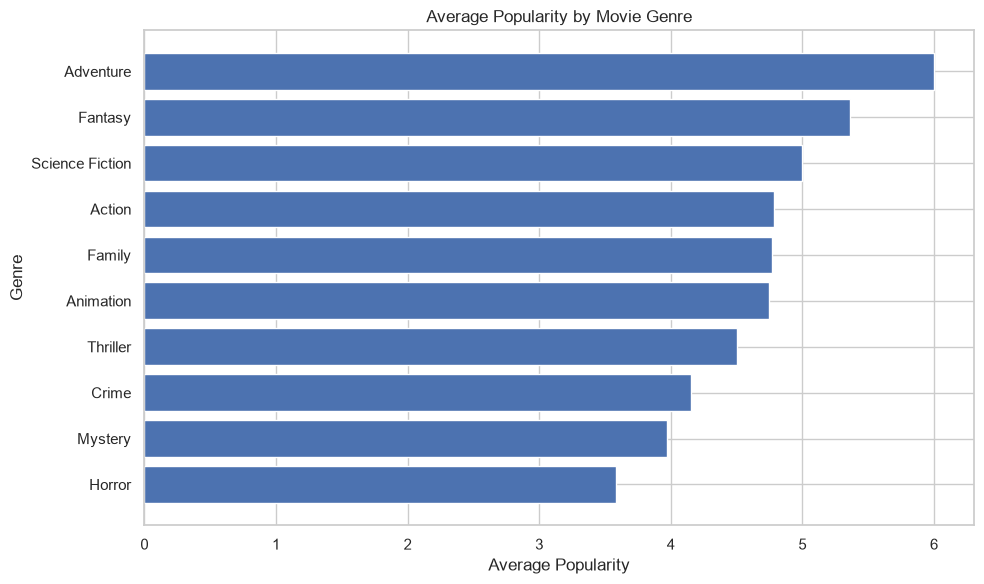

In [191]:
genre_plot = genre_summary.head(10).sort_values("mean")

plt.figure(figsize=(10, 6))

plt.barh(
    genre_plot.index,
    genre_plot["mean"]
)

plt.title("Average Popularity by Movie Genre")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

**Interpretation:** Adventure movies have the highest average popularity among the top genres analyzed, followed by Fantasy and Science Fiction. Action, Family, and Animation also show relatively high average popularity, while Horror and Mystery have lower average popularity. Overall, the results suggest that genre is associated with differences in audience attention, although average popularity alone does not indicate that genre causes higher popularity.

### 6.5 Movie Runtime and Popularity

Movie runtime can influence the viewing experience and may be associated with audience interest. This section examines the relationship between movie duration and popularity to determine whether longer or shorter movies tend to receive greater attention.

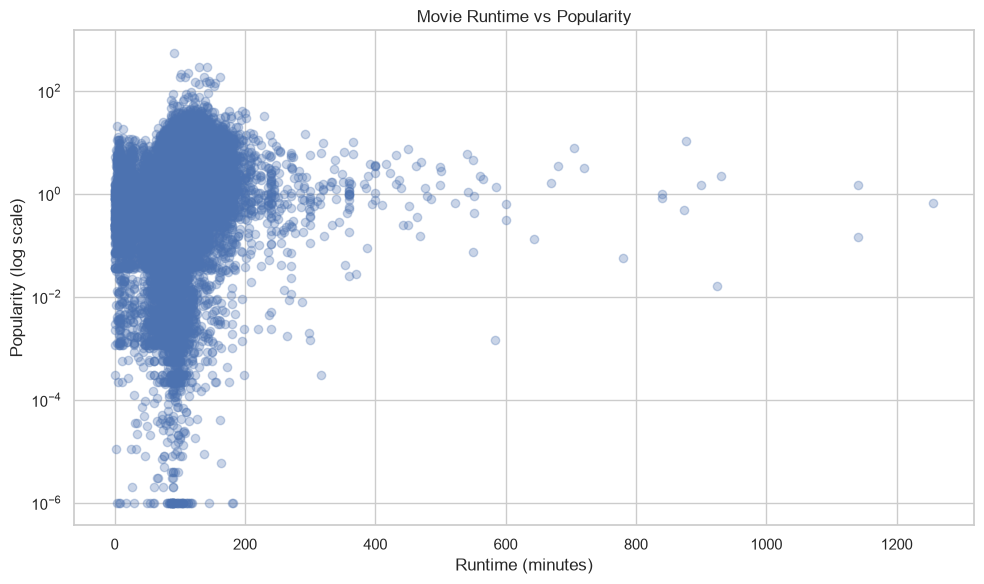

In [195]:
runtime_popularity = (
    df_clean[["runtime", "popularity"]]
    .dropna(subset=["runtime", "popularity"])
)

plt.figure(figsize=(10, 6))

plt.scatter(
    runtime_popularity["runtime"],
    runtime_popularity["popularity"],
    alpha=0.3
)

plt.yscale("log")

plt.title("Movie Runtime vs Popularity")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Popularity (log scale)")

plt.tight_layout()
plt.show()

**Interpretation:** The relationship between movie runtime and popularity appears weak and highly dispersed. Most movies fall within a runtime of approximately 60 to 180 minutes, but popularity varies substantially across this range. Very long movies are relatively uncommon and do not consistently show higher popularity. This suggests that movie runtime alone is not a strong indicator of audience popularity.

In [198]:
df_clean.columns.tolist()

['id',
 'title',
 'tagline',
 'release_date',
 'genres',
 'belongs_to_collection',
 'original_language',
 'budget_musd',
 'revenue_musd',
 'production_companies',
 'production_countries',
 'vote_count',
 'vote_average',
 'popularity',
 'runtime',
 'cast',
 'cast_size',
 'crew_size',
 'director',
 'release_year']

### 6.6 Movie Budget and Revenue

Movie budget represents the financial investment made in producing a movie, while revenue indicates the earnings generated from its release.

This section examines the relationship between production budget and movie revenue to determine whether higher-budget movies tend to generate higher revenues.

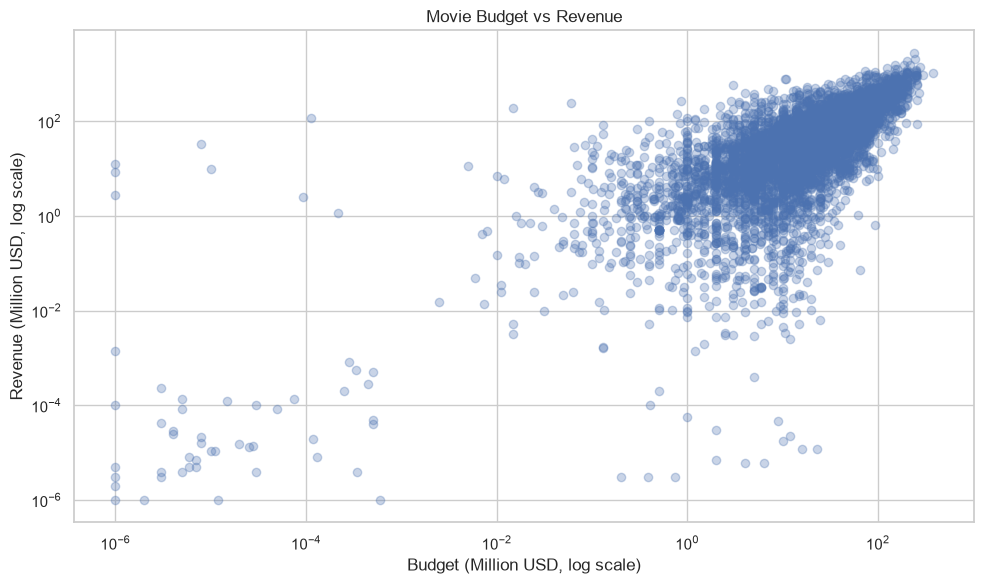

In [201]:
budget_revenue = (
    df_clean[["budget_musd", "revenue_musd"]]
    .dropna()
)

budget_revenue = budget_revenue[
    (budget_revenue["budget_musd"] > 0) &
    (budget_revenue["revenue_musd"] > 0)
]

plt.figure(figsize=(10, 6))

plt.scatter(
    budget_revenue["budget_musd"],
    budget_revenue["revenue_musd"],
    alpha=0.3
)

plt.xscale("log")
plt.yscale("log")

plt.title("Movie Budget vs Revenue")
plt.xlabel("Budget (Million USD, log scale)")
plt.ylabel("Revenue (Million USD, log scale)")

plt.tight_layout()
plt.show()

**Interpretation:** The analysis shows a clear positive relationship between movie budget and revenue. Movies with higher production budgets generally tend to generate higher revenues, although substantial variation exists, particularly among lower-budget movies. This indicates that greater financial investment is associated with higher earning potential, but budget alone does not guarantee strong revenue performance.

## 7. Business Questions

### Q1. How has movie production changed over time?

The number of movies released increased substantially over the years, with particularly rapid growth in movie production from the 1990s onward. The dataset shows a strong upward trend in annual movie releases, although the final year (2017) was excluded from the trend visualization because it appears incomplete.

### Q2. Does audience engagement influence movie popularity?

Movies with higher vote counts generally tend to have higher popularity. The analysis shows a clear positive relationship between audience engagement and popularity, although the relationship is not perfectly linear and substantial variation exists at lower levels of engagement.

### Q3. Which movie genres attract the highest audience interest?

Adventure movies have the highest average popularity among the major genres analyzed, followed by Fantasy and Science Fiction. Action, Family, and Animation also show relatively high average popularity, while Horror has the lowest average popularity among the top ten genres examined.

### Q4. Does movie runtime strongly influence popularity?

The relationship between movie runtime and popularity appears weak and highly dispersed. Most movies have runtimes between approximately 60 and 180 minutes, but popularity varies substantially within this range. Very long movies are relatively uncommon and do not consistently achieve higher popularity, suggesting that runtime alone is not a strong indicator of audience popularity.

### Q5. Does a higher movie budget lead to higher revenue?

Movies with higher production budgets generally tend to generate higher revenues, showing a clear positive relationship between budget and revenue. However, substantial variation exists, particularly among lower-budget movies. This indicates that greater financial investment is associated with higher earning potential, but budget alone does not guarantee strong revenue performance.

## 8. Key Insights

- **Movie production has increased significantly over time**, with particularly strong growth in the number of releases from the 1990s onward.

- **Audience engagement is strongly associated with movie popularity.** Movies with higher vote counts generally tend to receive higher popularity scores, although the relationship is not perfectly linear.

- **Adventure movies show the highest average popularity** among the major genres analyzed, followed by Fantasy and Science Fiction.

- **Movie runtime is not a strong indicator of popularity.** Most movies fall within approximately 60–180 minutes, but popularity varies substantially within this range.

- **Movie budget has a positive relationship with revenue.** Higher-budget movies generally tend to generate higher revenues, but financial investment alone does not guarantee strong revenue performance.

## 9. Conclusion

This exploratory data analysis examined movie production trends, audience ratings, popularity, engagement, genres, runtime, budget, and revenue to identify factors associated with movie performance.

The analysis shows that movie production has increased substantially over time, while audience engagement has a clear positive association with movie popularity. Genre also appears to be associated with differences in audience interest, with Adventure, Fantasy, and Science Fiction showing the highest average popularity among the major genres analyzed.

In contrast, movie runtime shows a weak relationship with popularity, indicating that longer movies do not necessarily attract greater audience attention. Movie budget has a positive relationship with revenue, suggesting that higher financial investment can increase earning potential, although budget alone does not guarantee commercial success.

Overall, the findings demonstrate that movie performance is influenced by multiple factors rather than a single variable. Audience engagement, genre, production scale, and financial investment can provide useful signals for understanding movie popularity and revenue performance.